### Generate thresholds for each smFISH target based on true signal vs background signal

In [2]:
from ioMicro import *

##### Load the raw images in to view and draw layers of polygons around positive/negative signal cells

In [252]:
from dask import array as da
import napari


fls = glob.glob(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\H*\Conv_zscan__126.zarr')
ims = []
for fl in fls[1:-1]:
    ims.append(read_im(fl)[np.newaxis])
ims = da.concatenate(ims)

V = napari.view_image(ims)

##### Select two shape layers of polygons, one for positive (transfected cells) and another for background signal

In [304]:
# load in the coordinates of the masks you drew
coords_neg = [X[:,-2:]for X in V.layers[-1].data] # most recent layer
coords_pos = [X[:,-2:]for X in V.layers[-2].data]

##### Load in a reference hybe, then define positive and negative points (using 1 color channel)

In [531]:
from shapely import Polygon,Point

# specific to this fov and color channel, assumption is that hybe shouldn't matter so much
fov = 126
CRE = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{fov:03d}--H{5}_fits_icol{1}.npz')['Xh']

pols_pos = [Polygon(X) for X in coords_pos]
pols_neg = [Polygon(X) for X in coords_neg]

vol_pos = np.sum([p.area for p in pols_pos])
vol_neg = np.sum([p.area for p in pols_neg])

CREXY = CRE[:,1:3]

is_positive_cell = [np.any([pol.contains(Point(x)) for pol in pols_pos]) for x in CREXY]
is_negative_cell = [np.any([pol.contains(Point(x)) for pol in pols_neg]) for x in CREXY]

##### Plot brightness values from spots inside positive or negative cells for this fov & color channel

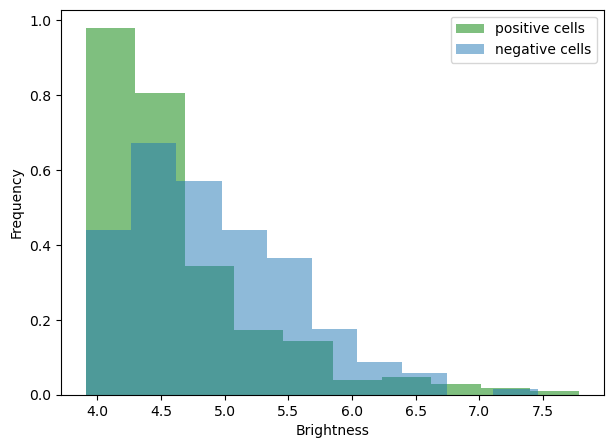

In [532]:
fig, ax = plt.subplots(figsize=(7,5))

ax.hist(np.log(CRE[is_positive_cell][:,-1]),density=True,alpha=0.5, color='g', label = 'positive cells')
ax.hist(np.log(CRE[is_negative_cell][:,-1]),density=True,alpha=0.5, label = 'negative cells')
ax.set_xlabel('Brightness')
ax.set_ylabel('Frequency')
ax.legend()

##### Choose threshold where negative cell signal drops off for this color channel

In [533]:
# Choose a threshold where the "contamination rate" is ~5-10% or lower, OR based off lowest contamination rate possible
th = np.exp(6.8)
density_pos = np.sum(CRE[is_positive_cell][:,-1]>th)/vol_pos
density_neg = np.sum(CRE[is_negative_cell][:,-1]>th)/vol_neg
print("contamination rate:",density_neg/density_pos)
print(th)
Nneg = np.sum(CRE[is_negative_cell][:,-1]>th) ### mask and color channel dependent, change Nneg number to corresponding color channel

contamination rate: 0.06813045412088792
897.8472916504176


In [542]:
# chosen for each CRE individually based on above criteria
ths = [121.5,148.4,181.2,
      221.4,812.4,445.9,
      244.7,244.7,221.4,
      330.3,270.4,221.4,
      221.4,897.8,200.3,
      148.5,270.4,148.4,
      221.4,270.4,148.4]

In [543]:
params = [(H,icol) for H in Hs for icol in icols]
final_params = [(H,icol,th)for th,(H,icol) in zip(ths,params)]

In [544]:
final_params

[(1, 0, 121.5),
 (1, 1, 148.4),
 (1, 2, 181.2),
 (2, 0, 221.4),
 (2, 1, 812.4),
 (2, 2, 445.9),
 (3, 0, 244.7),
 (3, 1, 244.7),
 (3, 2, 221.4),
 (4, 0, 330.3),
 (4, 1, 270.4),
 (4, 2, 221.4),
 (5, 0, 221.4),
 (5, 1, 897.8),
 (5, 2, 200.3),
 (6, 0, 148.5),
 (6, 1, 270.4),
 (6, 2, 148.4),
 (7, 0, 221.4),
 (7, 1, 270.4),
 (7, 2, 148.4)]

#### Fine tune thresholds based on manually looking through images: do they look reasonable?

Text(0.5, 1.0, 'raw data')

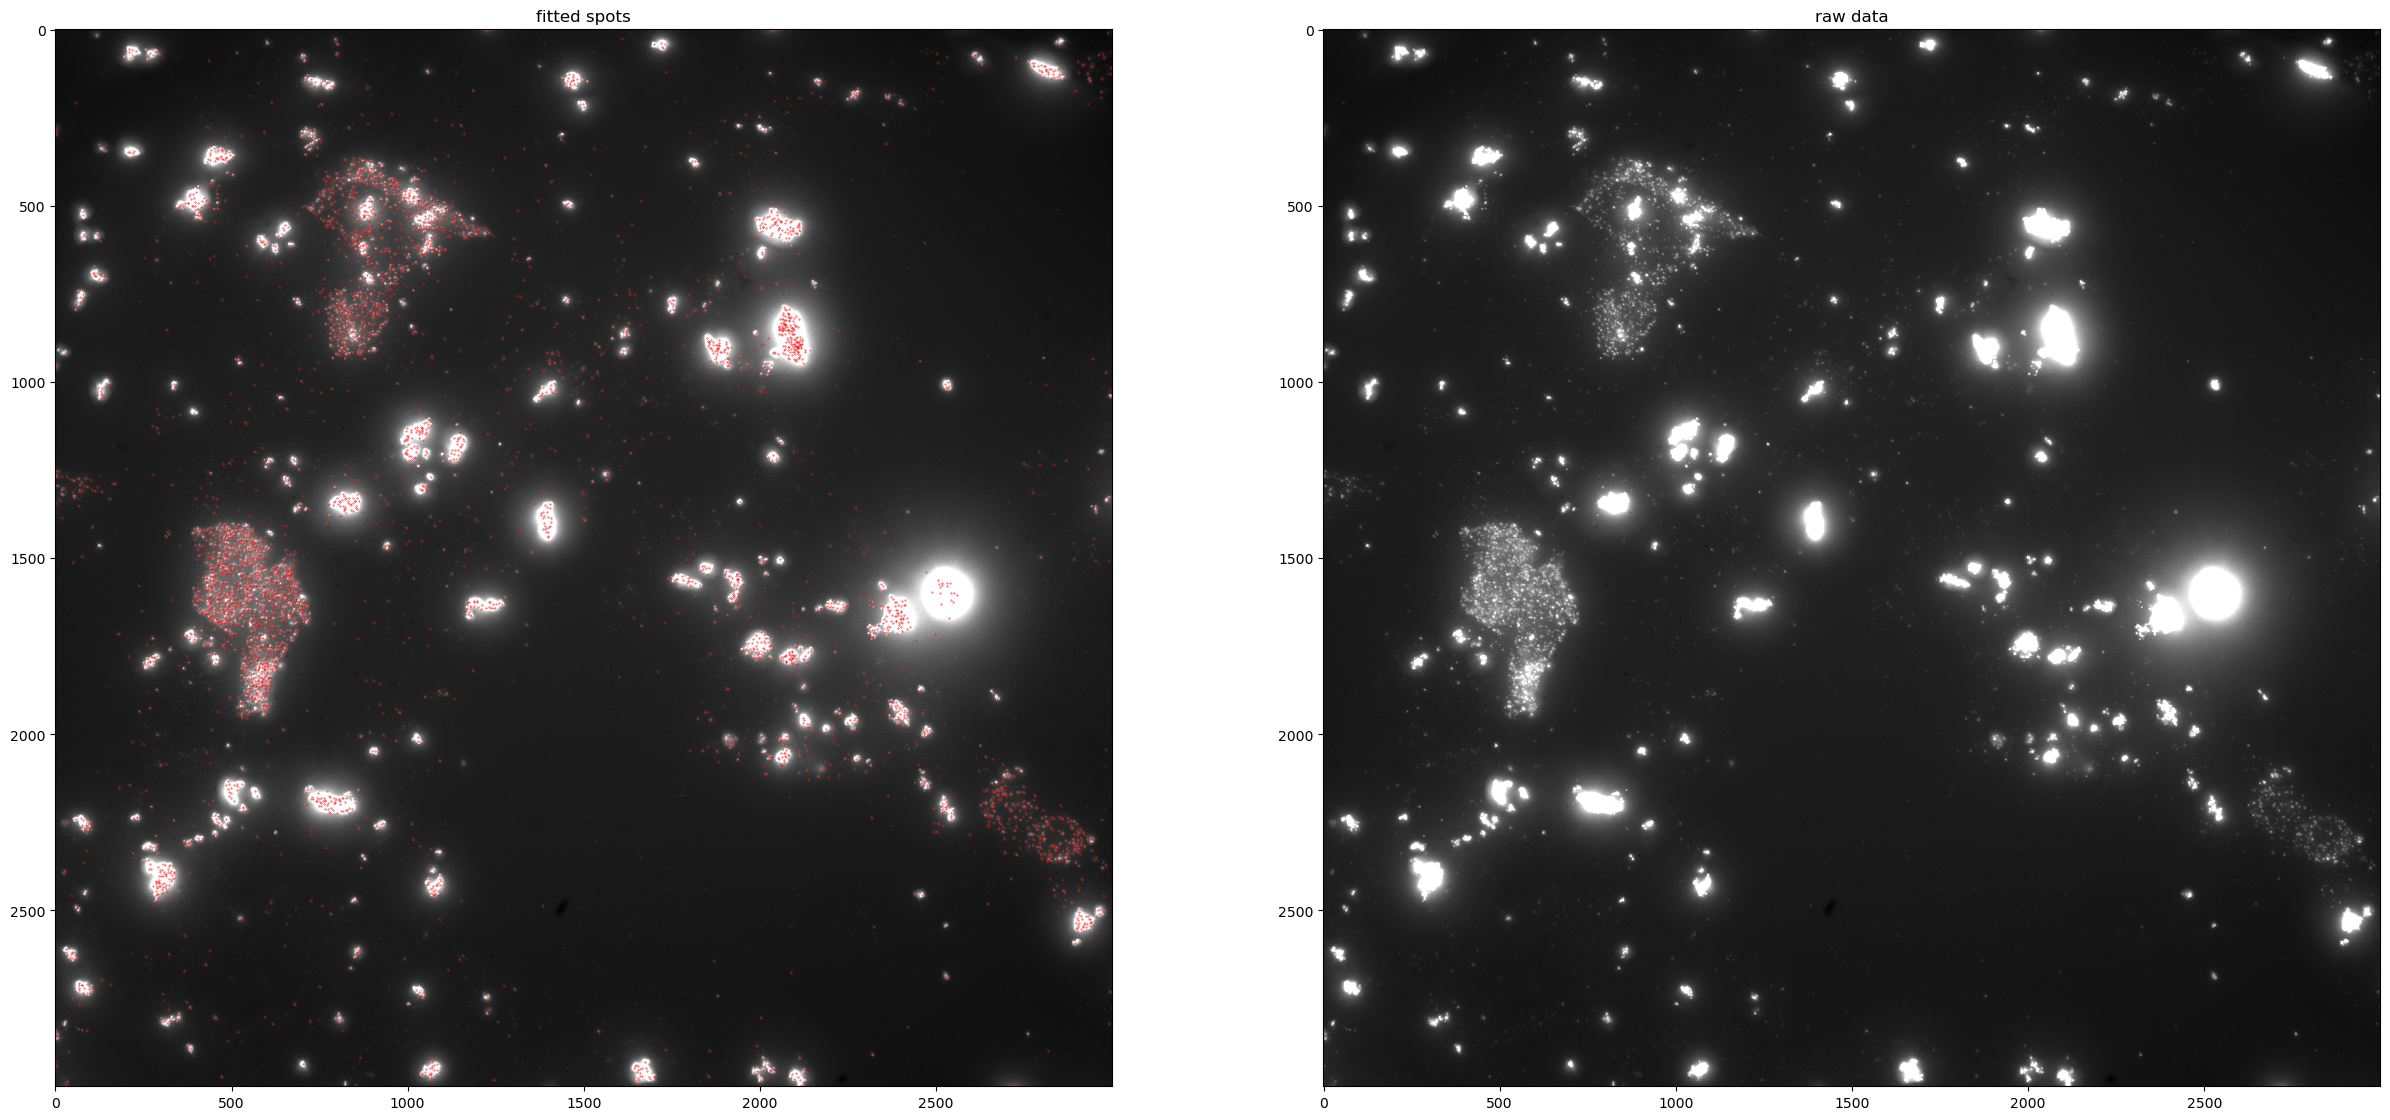

In [556]:
import matplotlib.pyplot as plt

CRE = np.load(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__126--H7_fits_icol1.npz')['Xh']
h = CRE[:,7]
keep = np.where(h>270.4)
CRE_ = CRE[keep]

img = read_im(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\H7\Conv_zscan__126.zarr')

fig, axs = plt.subplots(1, 2, figsize=(30,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE_[:,2], CRE_[:,1], s=0.1, c='r', marker='o')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].set_title('fitted spots')
axs[1].set_title('raw data')
# plt.gca().invert_yaxis()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240819_CRE020_fov100.pdf')

##### Get the thresholds across all the hybes and color channels for this fov

In [27]:
ths = []
Hs = [1,2,3,4,5,6,7]
icols = [0,1,2]
for H in tqdm(Hs):
    for icol in icols:
        CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{126}--H{H}_fits_icol{icol}.npz')['Xh']
        CREXY = CREN[:,1:3]
        
        drifts = np.load(f'Z:\\Zane_20CRE\\7_17_2024__T7_20CRE\\drifts_polyA\\Conv_zscan__{126}_drift.pkl', allow_pickle=True)
        drift = drifts[f'H{H:01d}'][0]
        CREXY-=drift
        
        is_positive_cellN = [np.any([pol.contains(Point(x)) for pol in pols_pos]) for x in CREXY]
        is_negative_cellN = [np.any([pol.contains(Point(x)) for pol in pols_neg]) for x in CREXY]
        th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg]
        ths.append(th_current)

        # if D == 1: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_001]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_002]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_003]

        # if D == 2: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_004]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_005]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_006]

        # if D == 3: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_007]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_008]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_009]

        # if D == 4: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_010]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_011]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_012]

        # if D == 5: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_013]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_014]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_015]

        # if D == 6: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_016]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_017]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_018]

        # if D == 7: 
        #     if icol == 0:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_019]
    
        #     if icol == 1:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_020]
            
        #     if icol == 2:
        #         th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_021]
        
        # ths.append(th_current)

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:16<00:00,  2.31s/it]


In [33]:
Ns = []
for (H,icol,th) in final_params:
    CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__150--H{H}_fits_icol{icol}.npz')['Xh']
    Ns.append(np.sum(CREN[:,-1]>th))

In [34]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.       , 0.7562266],
       [0.7562266, 1.       ]])

##### Load in plasmid sequencing data for this library

In [31]:
countsSeq = [eval(ln[:-1].split(' CRE')[0]) for ln in open(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts','r')]

In [379]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.        , 0.63095528],
       [0.63095528, 1.        ]])

In [398]:
OG_ths = np.load('final_parms_ths.npz')['final_parms']

In [406]:
OG_ths = OG_ths.astype(int)

In [456]:
Ns = []
for (D,icol,th) in OG_ths:
    CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__000--D{D}_fits_icol{icol}.npz')['Xh']
    Ns.append(np.sum(CREN[:,-1]>th))

In [457]:
Ns

[2269,
 3177,
 4091,
 2760,
 2121,
 1828,
 2688,
 2219,
 1868,
 1763,
 1368,
 2380,
 3759,
 1235,
 2067,
 1696,
 2920,
 3576,
 1934,
 2465,
 2036]

In [441]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.        , 0.81093792],
       [0.81093792, 1.        ]])

##### Create dataframe containing thresholded counts for each enhancer-barcode species across the dataset

In [35]:
CRE_id = []

for cre in range(1,21):
    id = f'CRE{cre:03d}'
    CRE_id.append(id)

CRE_id.append('blank')

In [545]:
total_ths_df = pd.DataFrame(index=CRE_id)

for fov in tqdm(range(225)):
    total_ths = []
    for (H,icol,th) in final_params:
        CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{fov:03d}--H{H}_fits_icol{icol}.npz')['Xh']
        total_ths.append(np.sum(CREN[:,-1]>th))

    total_ths_df[f'{fov:03d}'] = total_ths

# total_ths_df = total_ths_df.astype(int)

 44%|███████████████████████████████████▌                                            | 100/225 [01:09<02:03,  1.01it/s]C:\Users\zgibbs\AppData\Local\Temp\ipykernel_48936\2345223597.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  total_ths_df[f'{fov:03d}'] = total_ths
 45%|███████████████████████████████████▉                                            | 101/225 [01:10<01:54,  1.08it/s]C:\Users\zgibbs\AppData\Local\Temp\ipykernel_48936\2345223597.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  total_ths_df[f'{fov:03d}'] = 

In [546]:
total_ths_df

,000,001,002,003,004,005,006,007,008,009,...,215,216,217,218,219,220,221,222,223,224
CRE001,3600,6085,2112,1912,6347,7018,2788,3421,4467,2457,...,5771,4235,8107,8931,6340,6881,3166,419,5412,7020
CRE002,5328,8640,2840,2794,7756,9439,4815,5618,6886,3468,...,6807,4790,9968,12086,7825,8472,3431,471,6235,6575
CRE003,3977,7306,2615,1808,7812,8972,3862,3885,6374,2139,...,7606,4371,8131,11686,7289,8186,3461,129,5122,7102
CRE004,1772,3467,999,907,3687,4438,1495,1893,2872,1275,...,3066,2199,5176,4290,3257,3529,1329,37,2589,3700
CRE005,1737,3244,839,871,2776,3399,1491,1783,2373,1398,...,2714,2070,3957,3263,2382,2434,1270,11,1978,2488
CRE006,765,1047,290,488,1100,1154,794,749,949,964,...,1108,786,811,1253,843,699,467,0,739,759
CRE007,1456,1815,541,670,1788,1656,1124,1155,1681,1170,...,1971,1291,1873,2675,1863,1992,975,31,1388,1429
CRE008,1901,4000,997,953,2827,2898,1658,2113,2764,1479,...,2881,1943,3811,4388,2900,3120,1416,61,2538,2868
CRE009,1378,1975,572,827,1953,1976,1248,1396,1936,1379,...,1711,1176,1478,2108,1585,1346,747,18,1304,1290
CRE010,741,1180,317,494,1139,1151,778,938,1062,919,...,1092,837,926,1219,896,941,437,7,902,809


##### Plot the correlation between T7 transcripts and plasmid library counts

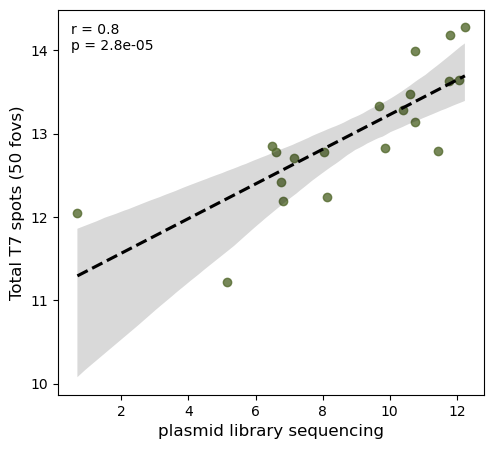

In [547]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(countsSeq)
y = np.log(total_ths_df[:-1].sum(axis=1))

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_xlabel('plasmid library sequencing', fontsize=12)
ax.set_ylabel('Total T7 spots (50 fovs)', fontsize=12)
# ax.set_yscale('log')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ_rep/figures/bulk_RNA-seq_corr_between_reps.png', dpi=600)
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_48936\126071440.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (x[i], y[i]), **kwargs)


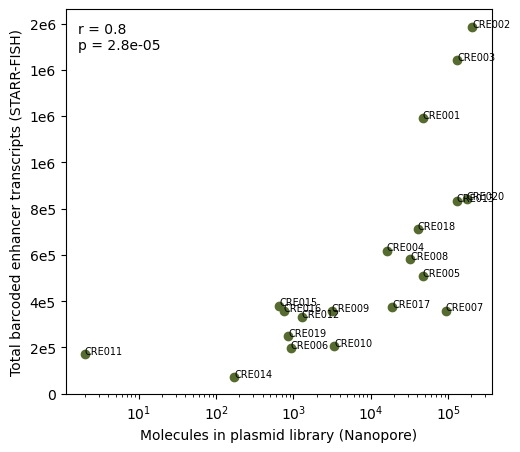

In [555]:
from scipy import stats
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

majorFormatter = FuncFormatter(MyFormatter)

x = countsSeq
y = total_ths_df[:-1].sum(axis=1)

fig, ax = plt.subplots(figsize=(5.5,5))

ax.loglog(x, y, 'o', c='darkolivegreen')

ax.set_yscale('linear')
ax.set_xlabel('Molecules in plasmid library (Nanopore)')
ax.set_ylabel('Total barcoded enhancer transcripts (STARR-FISH)')
ax.yaxis.set_major_formatter(majorFormatter)

stats = stats.pearsonr(np.log(x), np.log(y))
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)


# add labels to each point on the scatter plot
kwargs = {'size':'7'}
for i, txt in enumerate(total_ths_df[:-1].index):
    ax.annotate(txt, (x[i], y[i]), **kwargs)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\enhancer_spots_vs_nanopore_corr_log_250321.pdf')
plt.show()

##### Allows you to set tick labels to scientific notation

In [40]:
def MyFormatter(x,lim):
    if x == 0:
        return 0
    return '{0:.0f}e{1:.0f}'.format(np.sign(x)*10**(-np.floor(np.log10(abs(x)))+np.log10(abs(x))),np.floor(np.log10(abs(x))))
    #The first argument of the format gives the first significant digits of the number with the sign preserved and brought to a range between [1-10), The next argument gives the  numbers integer exponent of 10
    #Both the first and second arguments are formatted to display only 2 decimal places due to the lack of space.


##### Save the final threshold parameters

In [549]:
np.savez('enhancer_final_params_ths.npz',final_params=final_params)
#final_parms

In [432]:
final_params

[(1, 0, 121.5),
 (1, 1, 148.4),
 (1, 2, 181.2),
 (2, 0, 221.4),
 (2, 1, 812.4),
 (2, 2, 445.9),
 (3, 0, 244.7),
 (3, 1, 244.7),
 (3, 2, 221.4),
 (4, 0, 330.3),
 (4, 1, 54.6),
 (4, 2, 221.4),
 (5, 0, 221.4),
 (5, 1, 1096.6),
 (5, 2, 200.3),
 (6, 0, 148.5),
 (6, 1, 270.4),
 (6, 2, 148.4),
 (7, 0, 221.4),
 (7, 1, 270.4),
 (7, 2, 148.4)]